# Data loading


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [41]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# EDA

In [42]:
df.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [43]:
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [44]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [45]:
df.shape

(1338, 7)

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [47]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


<Axes: xlabel='smoker', ylabel='count'>

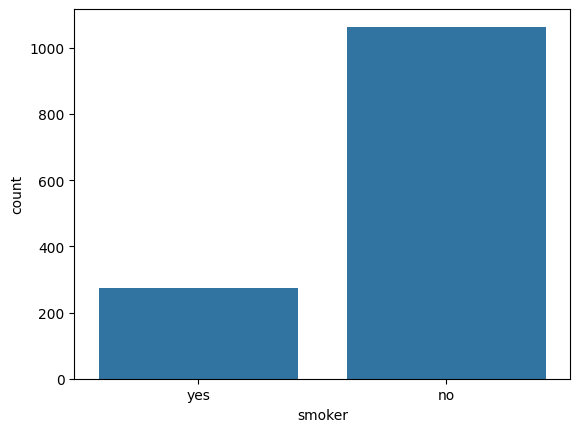

In [48]:
sns.countplot(x='smoker',data=df)

<Axes: xlabel='sex', ylabel='count'>

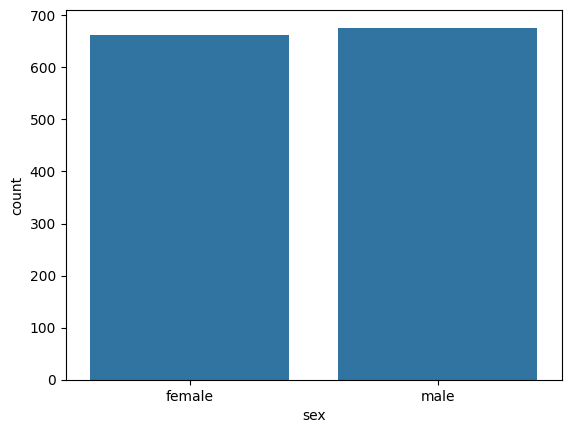

In [49]:
sns.countplot(x='sex',data=df)

In [50]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols

['age', 'bmi', 'children', 'charges']

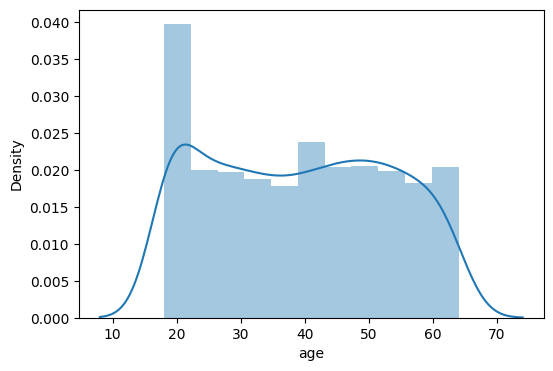

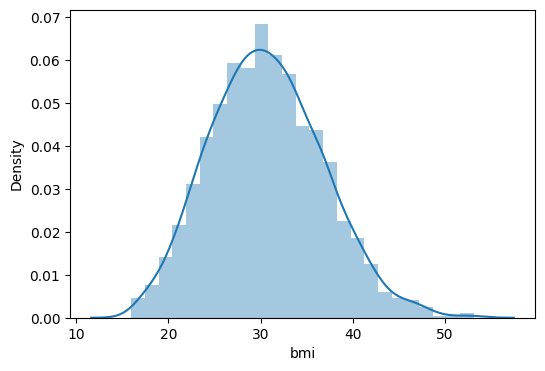

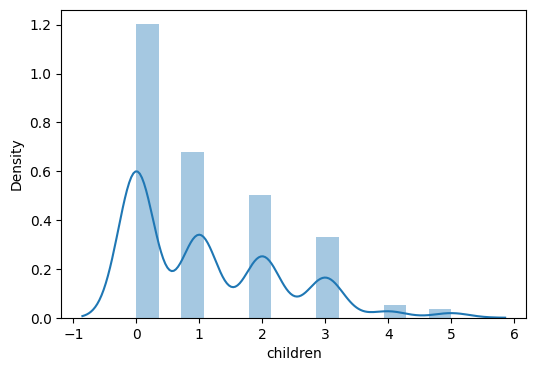

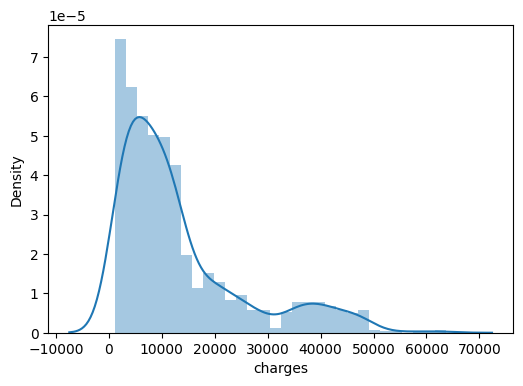

In [51]:
for cols in numeric_cols:
  plt.figure(figsize=(6,4))
  sns.distplot(df[cols])
  plt.show()

<Axes: xlabel='children', ylabel='count'>

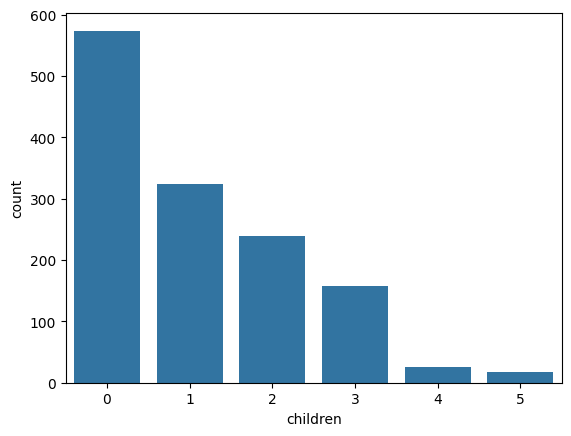

In [52]:
sns.countplot(x='children',data=df)

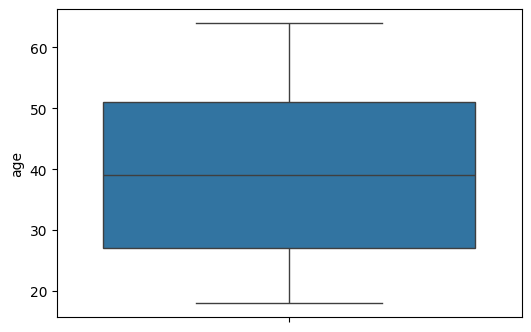

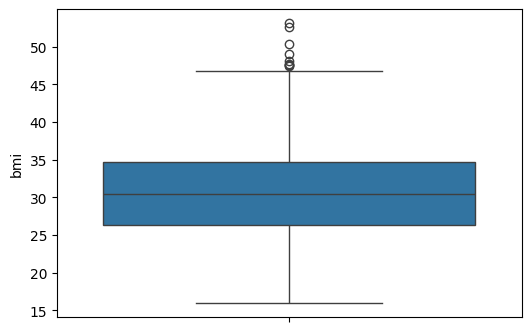

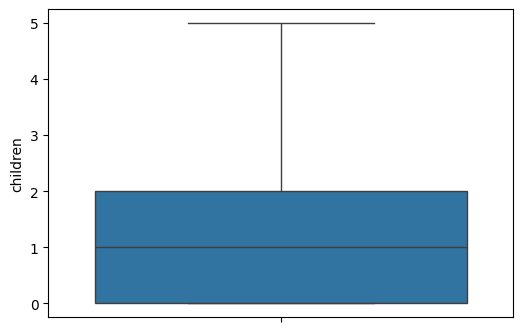

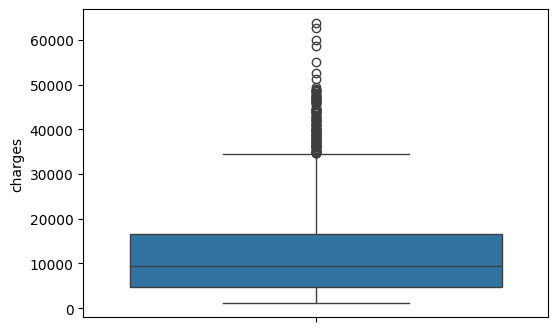

In [53]:
for cols in numeric_cols:
  plt.figure(figsize=(6,4))
  sns.boxplot(df[cols])
  plt.show()

<Axes: >

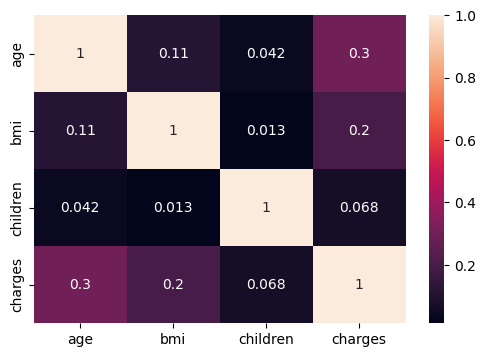

In [54]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [55]:
df_clean = df.copy()

In [56]:
df_clean.duplicated().sum()
df_clean.drop_duplicates(inplace=True)

In [57]:
df_clean.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [58]:
df_clean.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [59]:
# lable encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_clean['sex'] = le.fit_transform(df_clean['sex'])
df_clean['smoker'] = le.fit_transform(df_clean['smoker'])

In [60]:
# one hot encoding
df_clean = pd.get_dummies(df_clean,columns=['region'],drop_first=True)
df_clean = df_clean.astype(int)


In [61]:
from scipy.sparse.csgraph import depth_first_order

df_clean['bmi_category'] = pd.cut(df_clean['bmi'], bins = [0, 18.5, 24.9, 29.9, np.inf], labels=[ 'Underweight','Normal', 'Overweight','Obese' ])



In [62]:
df_clean.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,0,27,0,1,16884,0,0,1,Overweight
1,18,1,33,1,0,1725,0,1,0,Obese
2,28,1,33,3,0,4449,0,1,0,Obese
3,33,1,22,0,0,21984,1,0,0,Normal
4,32,1,28,0,0,3866,1,0,0,Overweight


In [63]:
#one hot encoding
df_clean = pd.get_dummies(df_clean,columns=['bmi_category'],drop_first=True)
df_clean = df_clean.astype(int)

In [64]:
df_clean.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,0,27,0,1,16884,0,0,1,0,1,0
1,18,1,33,1,0,1725,0,1,0,0,0,1
2,28,1,33,3,0,4449,0,1,0,0,0,1
3,33,1,22,0,0,21984,1,0,0,1,0,0
4,32,1,28,0,0,3866,1,0,0,0,1,0


Infant / Toddler: 0–3
yearsChild: 4–12
yearsTeenager: 13–19
yearsYoung Adult: 20–25
yearsAdult: 26–39
yearsMiddle-aged: 40–59
yearsSenior: 60+ years




In [65]:
df_clean['age_catagory'] = pd.cut(
    df_clean['age'],
    bins = [3, 12, 19, 25, 45, np.inf],   # 6 values
    labels = ['child', 'teen', 'young', 'adult', 'senior'], # 5 labels
)

In [66]:
df_clean.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese,age_catagory
0,19,0,27,0,1,16884,0,0,1,0,1,0,teen
1,18,1,33,1,0,1725,0,1,0,0,0,1,teen
2,28,1,33,3,0,4449,0,1,0,0,0,1,adult
3,33,1,22,0,0,21984,1,0,0,1,0,0,adult
4,32,1,28,0,0,3866,1,0,0,0,1,0,adult


In [67]:
#one hot encoding
df_clean = pd.get_dummies(df_clean,columns=['age_catagory'],drop_first=True)
df_clean = df_clean.astype(int)

In [68]:
df_clean.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese,age_catagory_teen,age_catagory_young,age_catagory_adult,age_catagory_senior
0,19,0,27,0,1,16884,0,0,1,0,1,0,1,0,0,0
1,18,1,33,1,0,1725,0,1,0,0,0,1,1,0,0,0
2,28,1,33,3,0,4449,0,1,0,0,0,1,0,0,1,0
3,33,1,22,0,0,21984,1,0,0,1,0,0,0,0,1,0
4,32,1,28,0,0,3866,1,0,0,0,1,0,0,0,1,0


In [69]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
cols = ['age', 'bmi', 'children', 'smoker']
df_clean[cols] = scaler.fit_transform(df_clean[cols])

In [70]:
df_clean.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese,age_catagory_teen,age_catagory_young,age_catagory_adult,age_catagory_senior
0,-1.440418,0,-0.517949,-0.909234,1.969660,16884,0,0,1,0,1,0,1,0,0,0
1,-1.511647,1,0.462463,-0.079442,-0.507702,1725,0,1,0,0,0,1,1,0,0,0
2,-0.799350,1,0.462463,1.580143,-0.507702,4449,0,1,0,0,0,1,0,0,1,0
3,-0.443201,1,-1.334960,-0.909234,-0.507702,21984,1,0,0,1,0,0,0,0,1,0
4,-0.514431,1,-0.354547,-0.909234,-0.507702,3866,1,0,0,0,1,0,0,0,1,0


In [71]:
df_clean.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese',
       'age_catagory_teen', 'age_catagory_young', 'age_catagory_adult',
       'age_catagory_senior'],
      dtype='object')

In [72]:
# Applying Person correlaation

from scipy.stats import pearsonr
selected_feature = ['age', 'sex', 'bmi', 'children', 'smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese']

correlations = {
    feature: pearsonr(df_clean[feature], df_clean['charges'])[0]
    for feature in selected_feature
}

correlations_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Correlation'])
correlations_df = correlations_df.sort_values(by='Correlation', ascending=False)
print(correlations_df)


                    Feature  Correlation
5                   charges     1.000000
4                    smoker     0.787234
0                       age     0.298309
11       bmi_category_Obese     0.200348
2                       bmi     0.196236
7          region_southeast     0.073577
3                  children     0.067390
1                       sex     0.058046
6          region_northwest    -0.038695
8          region_southwest    -0.043637
9       bmi_category_Normal    -0.104042
10  bmi_category_Overweight    -0.120601


In [73]:
cat_features = [
    'sex', 'smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
]

In [74]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

# Create bins for charges (4 equal-sized bins)
df_clean['charges_bin'] = pd.qcut(df_clean['charges'], q=4, labels=False)

chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df_clean[col], df_clean['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_results_df = pd.DataFrame(chi2_results).T
chi2_results_df = chi2_results_df.sort_values(by='p_value')
print(chi2_results_df)

                        chi2_statistic   p_value                    Decision
smoker                      848.219178       0.0  Reject Null (Keep Feature)
region_southeast             15.998167  0.001135  Reject Null (Keep Feature)
sex                          10.258784   0.01649  Reject Null (Keep Feature)
bmi_category_Obese            8.515711  0.036473  Reject Null (Keep Feature)
region_southwest              5.091893  0.165191  Accept Null (Drop Feature)
bmi_category_Overweight        4.25149  0.235557  Accept Null (Drop Feature)
bmi_category_Normal           3.708088   0.29476  Accept Null (Drop Feature)
region_northwest               1.13424  0.768815  Accept Null (Drop Feature)


In [75]:
df_clean.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese',
       'age_catagory_teen', 'age_catagory_young', 'age_catagory_adult',
       'age_catagory_senior', 'charges_bin'],
      dtype='object')

In [76]:
final_df = df_clean[[
    'age',
    'sex',
    'bmi',
    'charges',
    'children',
    'smoker',
    'region_southeast',  # Keep this one (not in drop list)
    'bmi_category_Obese',  # Keep this one (not in drop list)
]]

In [77]:
final_df

,age,sex,bmi,charges,children,smoker,region_southeast,bmi_category_Obese
0,-1.440418,0,-0.517949,16884,-0.909234,1.969660,0,0
1,-1.511647,1,0.462463,1725,-0.079442,-0.507702,1,1
2,-0.799350,1,0.462463,4449,1.580143,-0.507702,1,1
3,-0.443201,1,-1.334960,21984,-0.909234,-0.507702,0,0
4,-0.514431,1,-0.354547,3866,-0.909234,-0.507702,0,0
...,...,...,...,...,...,...,...,...
1333,0.767704,1,-0.027743,10600,1.580143,-0.507702,0,1
1334,-1.511647,0,0.135659,2205,-0.909234,-0.507702,0,1
1335,-1.511647,0,0.952670,1629,-0.909234,-0.507702,1,1
1336,-1.297958,0,-0.844753,2007,-0.909234,-0.507702,0,0


In [80]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [81]:
X = final_df.drop('charges',axis=1)
y = final_df['charges']



In [123]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

In [124]:
model = LinearRegression()
model.fit(X_train,y_train)


LinearRegression()

In [131]:
y_pred = model.predict(X_test)
y_pred

array([ 7856.41808069,  5379.07145062, 14613.47489419, 32465.93193508,
        8955.35729283, 13336.43605749, 30199.07309038,  1403.40503994,
       11196.90873514, 10018.65838301, 10818.71629044, 32144.43533014,
       31550.26059902, 16230.55597963, 10285.99989714,  8488.6608457 ,
        5487.64476113, 32465.09672212,  3304.46601962,  3877.00422671,
        4760.01023433, 28796.29743032, 13870.98195763, 29541.88243902,
       31520.15678042,  6344.44675222, 35026.69683204, 37880.73853364,
       12490.06211178, 14238.95332785,  7573.09915473, 13049.08020135,
         516.21534048, 11339.74207305, 37584.28749479, 13356.84393437,
        3706.96614326,  4537.12786929, 31481.80485676,  8009.55465514,
        6075.79442888, 30404.81913857, 35276.56346051, 13099.59189682,
        7977.69705664,  2987.00634487,  5174.11237148,  7620.54073087,
        3522.89053725, 10388.99625751,  7820.00530896, 10505.68054495,
       30331.09138384,  4687.62077185, 11676.0149257 , 11446.77536361,
      

In [126]:
r2 = r2_score(y_test,y_pred)
print(r2)

0.8040712413347118


In [128]:
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print(adjusted_r2)

0.7987962362937232
